In [1]:
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

words = open('names.txt', 'r').read().splitlines()

# Implementing Back Propagation Manually for Tensors

In [2]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [3]:
block_size = 3

def build_dataset(words):
    X, Y = [], []
    
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) # 80%
Xdev, Ydev = build_dataset(words[n1:n2]) # 10%
Xte, Yte = build_dataset(words[n2:]) # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [4]:
# utility function we will use to compare our manual gradients to PyTorch's gradients
def cmp(s, dt, t):
    ex = torch.all(dt == t.grad).item()
    app = torch.allclose(dt, t.grad)
    maxdiff = (dt - t.grad).abs().max().item()
    print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [5]:
n_embd = 10 # dimension of the char embedding vectors
n_hidden = 64 # number of neurons in a hidden layer of the MLP

g = torch.Generator().manual_seed(21474836647)
C = torch.randn((vocab_size, n_embd),             generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / ((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1 # useless because of batch normalization
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden)) * 0.1 + 1.0
bnbias = torch.randn((1, n_hidden)) * 0.1

# non-standard implementation of some of these parameters for sake of manual implementation of backward pass

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


4137


In [6]:
batch_size = 32
n = batch_size # short name for convenience
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix]

In [ ]:
# forward pass "chunkated" into smaller steps that are possible to backward one at a time

emb = C[Xb] # embed chars into vectors
embcat = emb.view(emb.shape[0], -1) # concatenate into vectors
# Linear Layer 1
hprebn = embcat @ W1 + b1 # hidden layer pre-activation
# BatchNorm Layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note Bessel's correction: divide by n-1 not n
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# Non-linearity
h = torch.tanh(hpreact) # hidden layer
# Linear layer 2
logits = h @ W2 + b2 # ouput layer
# cross entropy loss (same as F.cross_entropy(logits, Yb))
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdim=True)
counts_sum_inv = counts_sum**-1
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass
for p in parameters:
    p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, 
            norm_logits, logit_maxes, logits, h, hpreact, bnraw, 
            bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani, 
            embcat, emb]:
    t.retain_grad()
loss.backward()
loss
    

tensor(3.4947, grad_fn=<NegBackward0>)

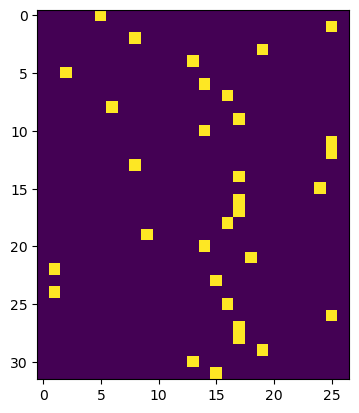

In [8]:
plt.imshow(F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]))

In [9]:
# Backprop through the whole network manually
# Backpropogate through exactly all variables as they are defined in the forward pass above, one by one
# General Note: Anytime you have a sum in the forward pass, that turns into a replication / broadcasting in the backward pass over the same dimension, and vice versa.

# dlogprobs holds the derivative of the loss with respect to all of the elements of logprobs
# so remember that logprobs is the log of the probabilities that the model assigns to chars
# and loss is -logprob(actual values from the training data).mean so we are seeing how well the model predicts the actual data (which it should predict with high prob)
# so d(loss)/d(logprob_i) = d/d(logprob_i) [(-1/size of training batch) * sum_i (logprob(training batch data point i))] = -1/(size of Yb)
# but that is only for the elements that participate in the computation of the loss (the elements of logprobs that are indexed out here: loss = -logprobs[range(n), Yb].mean())
# the rest are zero

# Backprop through cross entropy loss:
dlogprobs = torch.zeros_like(logprobs) 
dlogprobs[range(n), Yb] = -1.0 / n
dprobs = (1.0 / probs) * dlogprobs
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True) # at ~25 min: notes about broadcasting in PyTorch
dcounts = counts_sum_inv * dprobs
dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv
dcounts += torch.ones_like(counts) * dcounts_sum
dnorm_logits = counts * dcounts
dlogits = dnorm_logits.clone()
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)
# so remember that the reason we subtract logit maxes from logits for norm logits is that we want numerical stability - we dont want count = logits.exp() to blow up
# but the idea is that normalizing this does not impact the value of probs mathematically
# thus, gradient of logit maxes should be ~ zero, which we see
dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes
# above, we are distributing the value dlogit_maxes to the correct indices of dlogits (see cell above)
# you can kinda think of this as a convolution of dlogit_maxes with a 2D delta function that picks out the max value locations
# could also implement this simuilar to dlogprobs

# Backprop through lienear layer 2:
dh = dlogits @ W2.T
dW2 = h.T @ dlogits
db2 = dlogits.sum(0)
# @ roughly 47 minutes: matrix derivative
# you can also just do dimensional analysis

# Backprop through non-linearity:
dhpreact = (1.0 - h**2) * dh

# Backprop through batch norm:
dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
dbnraw = (bngain * dhpreact)
dbnbias = dhpreact.sum(0, keepdim=True)
dbndiff = bnvar_inv * dbnraw
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
dbnvar = (-0.5 * (bnvar  + 1e-5)**-1.5 ) * dbnvar_inv
dbndiff2 = (1.0 / (n-1)) * torch.ones_like(bndiff2) * dbnvar
dbndiff += (2*bndiff) * dbndiff2
dhprebn = dbndiff.clone()
dbnmeani = (-dbndiff).sum(0, keepdim=True)
dhprebn += (1.0 / n) * (torch.ones_like(dhprebn) * dbnmeani)

# Backprop through linear layer 1:
dembcat = dhprebn @ W1.T
dW1 = embcat.T @ dhprebn
db1 = dhprebn.sum(0)

# Backprop through embedding layer:
demb = dembcat.view(emb.shape)
dC = torch.zeros_like(C)
for k in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
        ix = Xb[k, j]
        dC[ix] += demb[k, j]

# Check accuracy of manual backprop against PyTorch backprop:
cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bnraw', dbnraw, bnraw)
cmp('bnbias', dbnbias, bnbias)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0
bnvar_inv       | exact: True  | approximate: True  | maxdiff:

In [11]:
# Backprop through cross entropy loss in a single expression
# Want d(loss)/d(logits_i) @ ~1:30 
# recall forward pass loss = F.cross_entropy(logits, Yb) = sum_x [p_Yb(x) * log(p_logits(x))] ?
# equivalently (?) for a single char: loss = -log(prob assigned to correct char Y) = -log(p_y) = -log(exp(logit_y) / sum_j [exp(logit_j)])
# Result: if i /= y, then derivative = p_i, and if i = y, then derivative = p_i - 1

dlogits = F.softmax(logits, dim=1)
dlogits[range(n), Yb] -= 1.0 # loss per element of batch
dlogits /= n # take average for batch loss

cmp('logits', dlogits, logits)

logits          | exact: False | approximate: True  | maxdiff: 6.984919309616089e-09


tensor([0.0232, 0.0121, 0.0217, 0.0323, 0.0290, 0.0858, 0.0538, 0.0497, 0.0326,
        0.0257, 0.0690, 0.0369, 0.0332, 0.0225, 0.0625, 0.0282, 0.0596, 0.0520,
        0.0347, 0.0418, 0.0426, 0.0263, 0.0143, 0.0382, 0.0219, 0.0236, 0.0267],
       grad_fn=<SelectBackward0>)
tensor([ 0.0232,  0.0121,  0.0217,  0.0323,  0.0290,  0.0858,  0.0538,  0.0497,
         0.0326,  0.0257,  0.0690,  0.0369,  0.0332,  0.0225,  0.0625, -0.9718,
         0.0596,  0.0520,  0.0347,  0.0418,  0.0426,  0.0263,  0.0143,  0.0382,
         0.0219,  0.0236,  0.0267], grad_fn=<MulBackward0>)
tensor(0., grad_fn=<SumBackward0>)


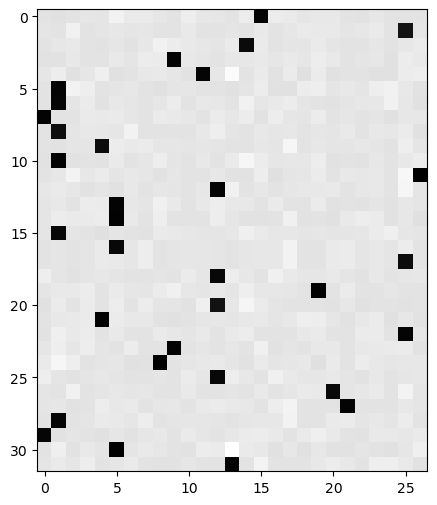

In [ ]:
# not about viewing dlogits as a force on gradients @ ~ 1:35
print(F.softmax(logits, dim=1)[0])
print(dlogits[0] * n)
print(dlogits[0].sum())
plt.figure(figsize=(6,6))
plt.imshow(dlogits.detach(), cmap='gray')

In [ ]:
# Backprop through batch norm latyer in a single expression

